In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.f import Model_f
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
a = Model_f()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[1.  1.  1.  1.  1.3 1.3 1.3 1.3 1.3 1.3 1.3]]]


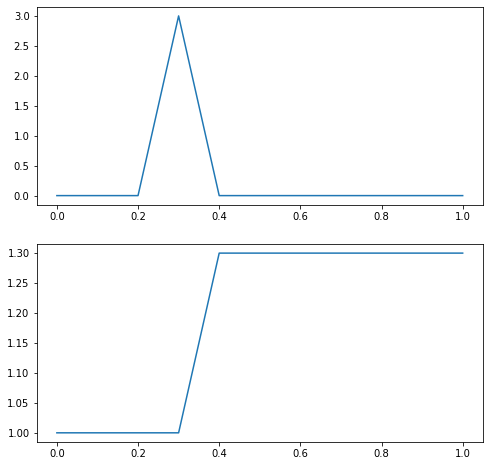

In [127]:
dur = 1.

a.params.duration = dur
target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,3] += 3.
#control1[0,0,:] += 10.*a.t[:]

a.run(control=control1)

target[:,0,:] = a.mufe[:,:]

fig, axes = plt.subplots(2, figsize=(8, 8))
axes[0].plot(a.t, control1[0,0,:])
axes[1].plot(a.t, a.state["mufe"][0,:])

print(target)

In [129]:
max_cntrl = 100. * 5.
start_step = 11.
cost_params = [1.0, 3.0, 0.0]

init_state_vars = np.array( [a.params.mufe_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()

max_it = 40

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#0.7262797905237487

set cost params
RUN  0 , total integrated cost =  0.03150000000000001
energy contribution =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
phi contribution =  [[[-0.   -0.21 -0.21 -0.21 -0.18 -0.15 -0.12 -0.09 -0.06 -0.03 -0.  ]]]
g =  [[[ 0.   -0.21 -0.21 -0.21 -0.18 -0.15 -0.12 -0.09 -0.06 -0.03  0.  ]]]
RUN  1 , total integrated cost =  0.028388510450977976
energy contribution =  [0.         0.18292688 0.18292688 0.18292688 0.15679447 0.13066206
 0.10452964 0.07839723 0.05226482 0.02613241 0.        ]
phi contribution =  [[[-0.         -0.18345534 -0.18405829 -0.18526006 -0.15727835
   -0.12999205 -0.1032826  -0.07703657 -0.05114457 -0.02550036
   -0.        ]]]
g =  [[[ 0.         -0.00052846 -0.00113142 -0.00233318 -0.00048389
    0.00067001  0.00124704  0.00136066  0.00112025  0.00063205
    0.        ]]]
RUN  2 , total integrated cost =  0.028388301175043495
energy contribution =  [0.         0.18344617 0.18403866 0.18521957 0.15726996 0.13000368
 0.10330425 0.07706018 0.05116401 0.0255113

RUN  17 , total integrated cost =  0.02838830101065938
energy contribution =  [0.         0.183394   0.18400219 0.1852163  0.15723901 0.12996513
 0.10326896 0.07703305 0.05114639 0.0255029  0.        ]
phi contribution =  [[[-0.         -0.18339408 -0.18400226 -0.18521637 -0.15723908
   -0.12996519 -0.10326901 -0.07703309 -0.05114642 -0.02550291
   -0.        ]]]
g =  [[[ 0.00000000e+00 -7.60530846e-08 -7.36648659e-08 -6.88202123e-08
   -6.43732890e-08 -5.71280607e-08 -4.78422605e-08 -3.70861051e-08
   -2.52990490e-08 -1.28356139e-08  0.00000000e+00]]]
RUN  18 , total integrated cost =  0.028388301010659367
energy contribution =  [0.         0.18339413 0.18400232 0.18521642 0.15723913 0.12996523
 0.10326905 0.07703312 0.05114644 0.02550292 0.        ]
phi contribution =  [[[-0.         -0.18339406 -0.18400224 -0.18521636 -0.15723906
   -0.12996518 -0.103269   -0.07703308 -0.05114641 -0.02550291
   -0.        ]]]
g =  [[[0.00000000e+00 7.54219725e-08 7.32257743e-08 6.88028665e-08
   6.4

RUN  34 , total integrated cost =  0.028388301010659048
energy contribution =  [0.         0.1833941  0.18400229 0.1852164  0.1572391  0.12996521
 0.10326903 0.0770331  0.05114643 0.02550291 0.        ]
phi contribution =  [[[-0.         -0.18339406 -0.18400225 -0.18521636 -0.15723907
   -0.12996518 -0.103269   -0.07703308 -0.05114642 -0.02550291
   -0.        ]]]
g =  [[[0.00000000e+00 4.09685097e-08 4.00544815e-08 3.82599791e-08
   3.50691462e-08 3.08896517e-08 2.58462300e-08 2.00785188e-08
   1.37386731e-08 6.98906129e-09 0.00000000e+00]]]
RUN  35 , total integrated cost =  0.028388301010659023
energy contribution =  [0.         0.18339404 0.18400222 0.18521634 0.15723905 0.12996516
 0.10326899 0.07703307 0.05114641 0.0255029  0.        ]
phi contribution =  [[[-0.         -0.18339407 -0.18400226 -0.18521637 -0.15723907
   -0.12996519 -0.10326901 -0.07703309 -0.05114642 -0.02550291
   -0.        ]]]
g =  [[[ 0.00000000e+00 -3.37190422e-08 -3.29673238e-08 -3.14915386e-08
   -2.886417

[[[0.         0.06113136 0.06133409 0.06173879 0.05241303 0.04332173
   0.03442301 0.0256777  0.01704881 0.00850097 0.        ]]]


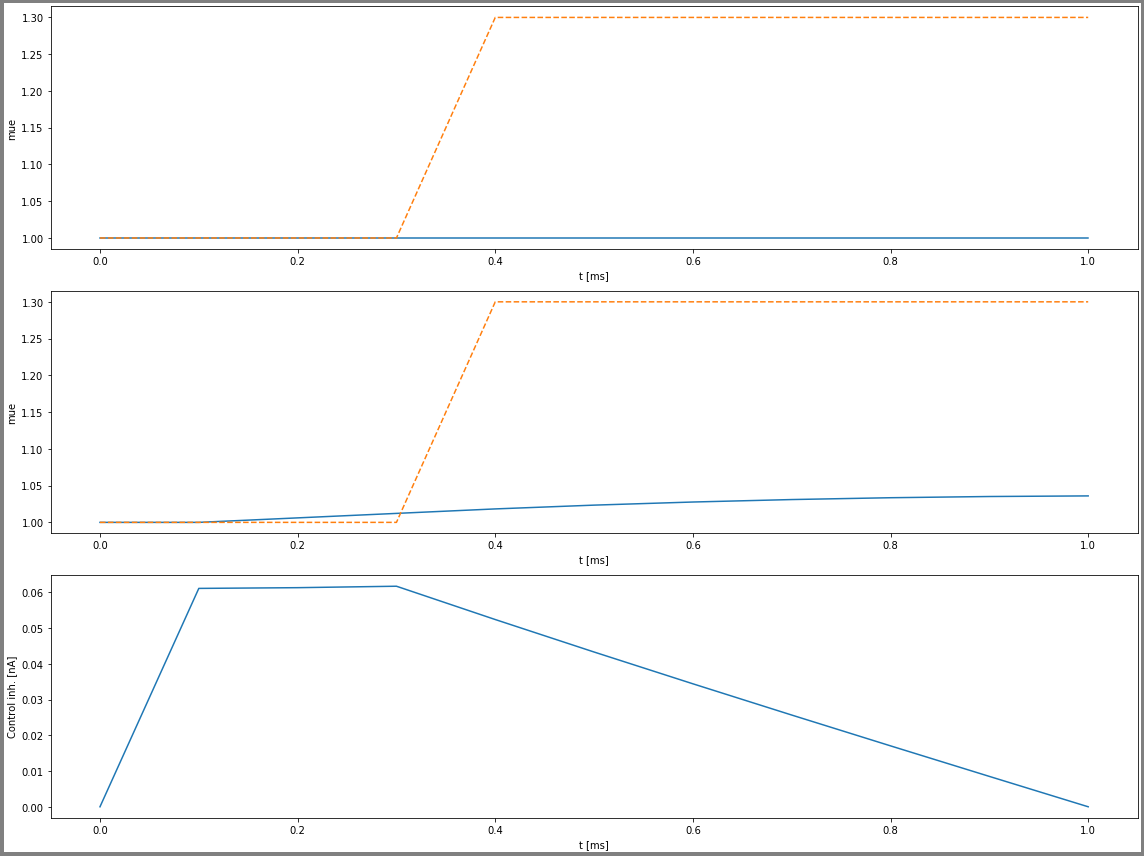

In [130]:
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [131]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 40

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  0.03150000000000001
RUN  1 , total integrated cost:  0.028401500789973784
change helped, counter =  1
RUN  2 , total integrated cost:  0.02838831508346585
change helped, counter =  1
change helped, counter =  2
change helped, counter =  1
change helped, counter =  2
RUN  3 , total integrated cost:  0.028388301012265613
change helped, counter =  4
change helped, counter =  1
change helped, counter =  1
RUN  4 , total integrated cost:  0.028388301010725543
change helped, counter =  3
change helped, counter =  3
RUN  5 , total integrated cost:  0.028388301010700362
Control only changes marginally.
RUN  6 , total integrated cost:  0.028388301010700362
Improved over  6  iterations by  10  percent.


[[[0.         0.06113138 0.06133433 0.06173834 0.05241308 0.04332179
   0.03442307 0.02567763 0.01704883 0.00850096 0.        ]]]


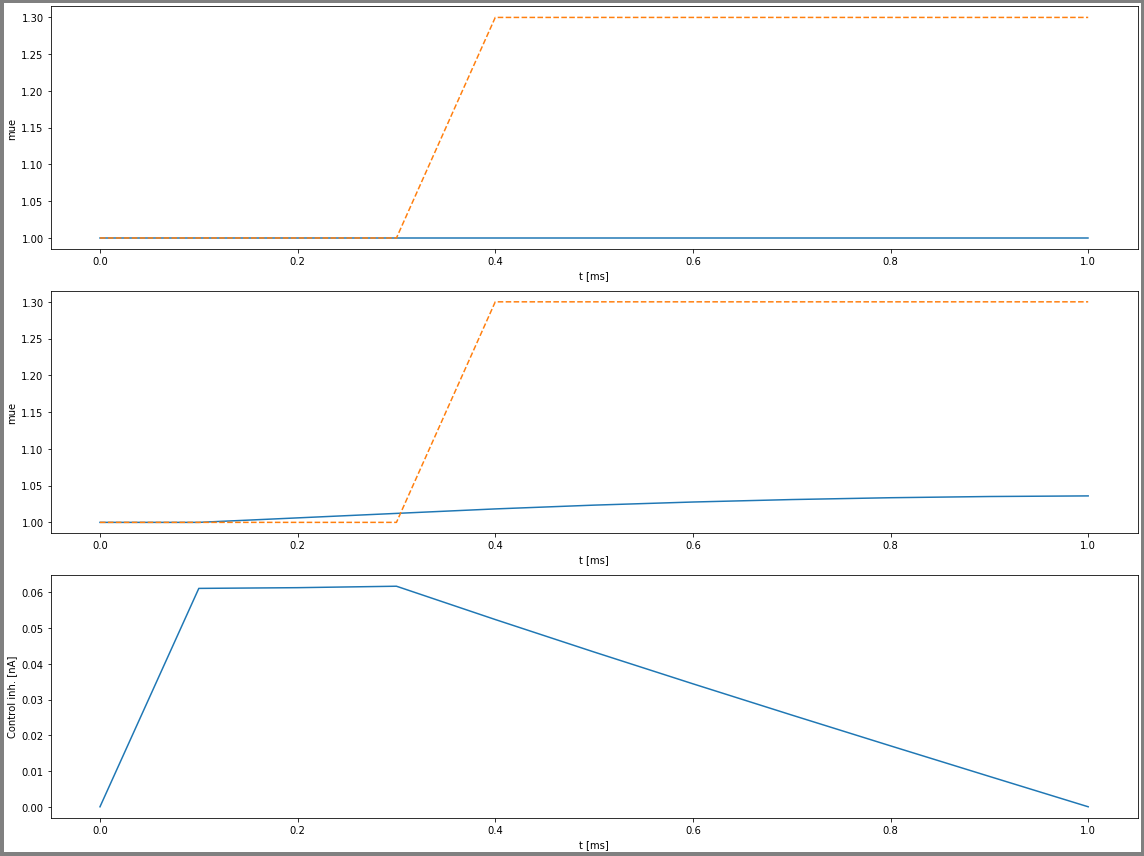

In [132]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

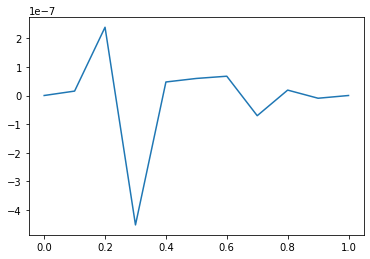

In [133]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


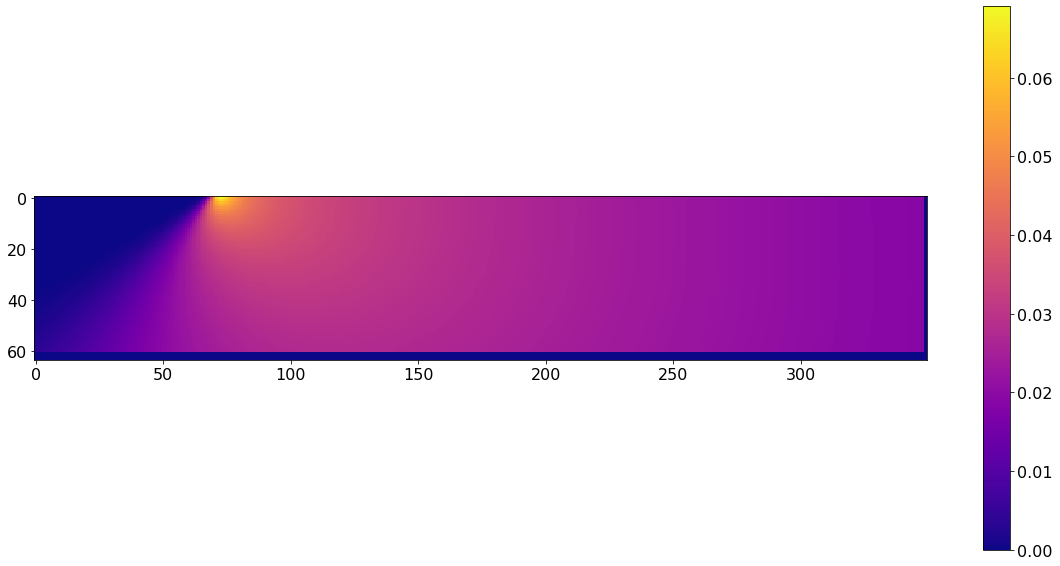

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


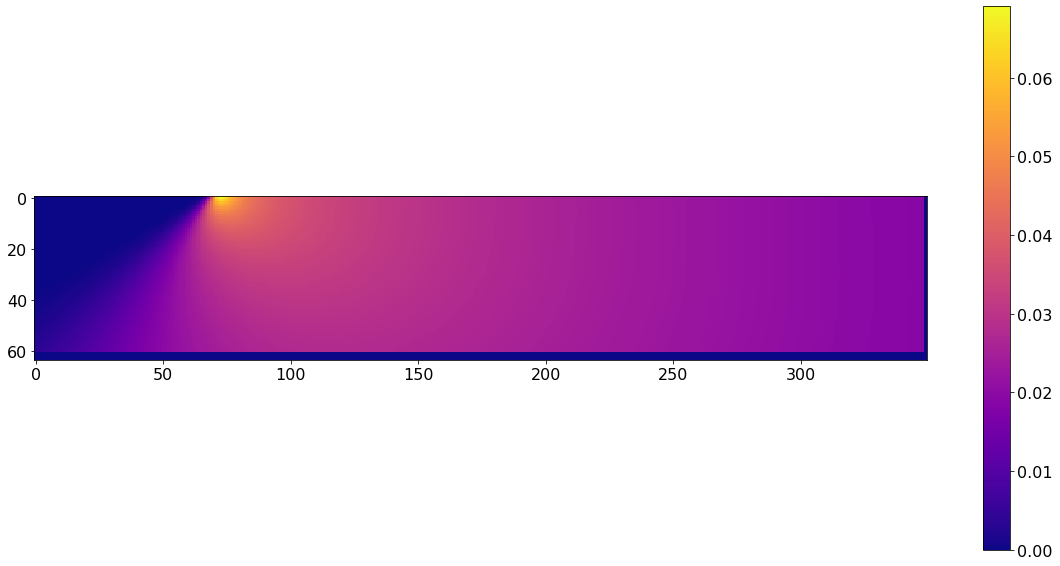

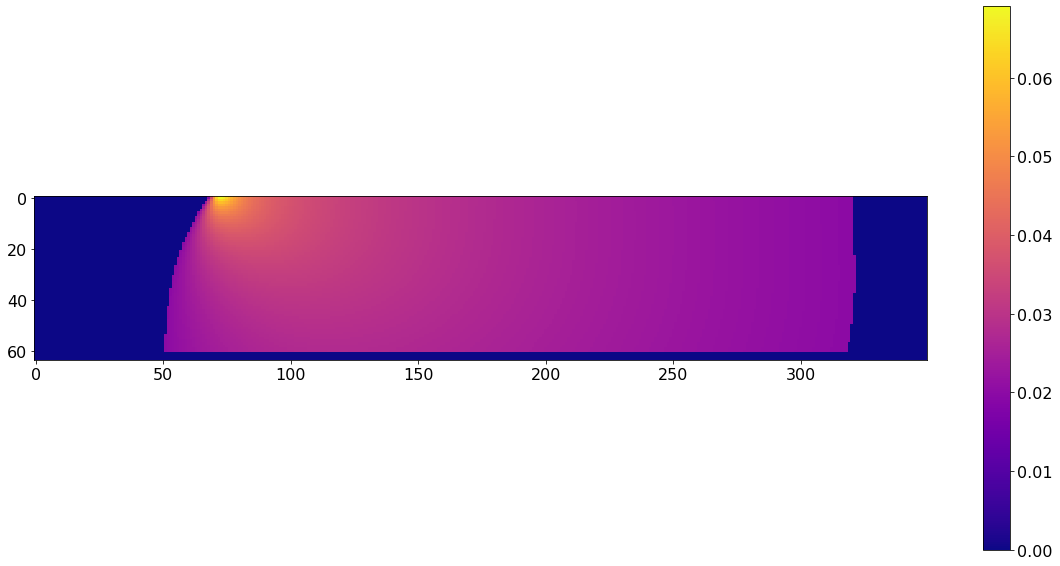

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()